Data cleaning n Visualization - Febuary 13, 2026 - angbur5378

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
file_path = r"C:\Files\Excel\DA_PythonR\AirBnBSummary_v2.xlsx" 
df = pd.read_excel(file_path) 
df.head() 

,id,host_id,host_name,neighbourhood,room_type,price,minimum_nights,number_of_reviews,availability_365,<StudentID>
0,7909479,41706311,David,Downtown,Entire home/apt,107.0,30,27,365.0,angbur5378
1,15966488,103700433,Erin,Downtown,Entire home/apt,100.0,1,250,74.0,angbur5378
2,19859814,103700433,Erin,Downtown,Entire home/apt,100.0,1,309,79.0,angbur5378
3,21071138,22992627,Joseph,Downtown,Entire home/apt,100.0,2,144,338.0,angbur5378
4,21712505,103700433,Erin,Downtown,Entire home/apt,100.0,1,178,68.0,angbur5378


In [3]:
df_cleaned = df.drop_duplicates() 
print("Duplicates removed:", df.shape[0] - df_cleaned.shape[0]) 

Duplicates removed: 4


In [6]:
numeric_cols = df_cleaned.select_dtypes(include=['number']).columns 
for col in numeric_cols: 
    median_value = df_cleaned[col].median() 
    df_cleaned[col] = df_cleaned[col].fillna(median_value) 

In [7]:
df_cleaned.isnull().sum()

id                   0
host_id              0
host_name            0
neighbourhood        0
room_type            0
price                0
minimum_nights       0
number_of_reviews    0
availability_365     0
<StudentID>          0
dtype: int64

In [10]:
text_cols = df_cleaned.select_dtypes(include=['object', 'string']).columns 
for col in text_cols: df_cleaned[col] = df_cleaned[col].str.lower() 

In [11]:
df_cleaned[text_cols].head()

,host_name,neighbourhood,room_type,<StudentID>
0,david,downtown,entire home/apt,angbur5378
1,erin,downtown,entire home/apt,angbur5378
2,erin,downtown,entire home/apt,angbur5378
3,joseph,downtown,entire home/apt,angbur5378
4,erin,downtown,entire home/apt,angbur5378


In [12]:
Q1 = df_cleaned['price'].quantile(0.25) 
Q3 = df_cleaned['price'].quantile(0.75) 
IQR = Q3 - Q1 
lower_bound = Q1 - 1.5 * IQR 
upper_bound = Q3 + 1.5 * IQR 
df_cleaned = df_cleaned[ 
    (df_cleaned['price'] >= lower_bound) & 
    (df_cleaned['price'] <= upper_bound) 
] 

In [13]:
output_path = r"C:\Files\Excel\DA_PythonR\AirBnB_Cleaned.xlsx" 
df_cleaned.to_excel(output_path, index=False) 
output_path 

'C:\\Files\\Excel\\DA_PythonR\\AirBnB_Cleaned.xlsx'

In [14]:
df_cleaned.shape[0]

1657

In [15]:
print("Total listings:", df_cleaned.shape[0]) 
print("Minimum price:", df_cleaned['price'].min()) 
print("Maximum price:", df_cleaned['price'].max()) 
print("Mean price:", df_cleaned['price'].mean()) 
print("Median number of reviews:", df_cleaned['number_of_reviews'].median()) 
print("Mode of minimum nights:", df_cleaned['minimum_nights'].mode()[0]) 
print("Standard deviation of price:", df_cleaned['price'].std()) 
print("Correlation (price vs availability_365):", 
df_cleaned['price'].corr(df_cleaned['availability_365'])) 

Total listings: 1657
Minimum price: 20.0
Maximum price: 308.0
Mean price: 124.13277006638504
Median number of reviews: 20.0
Mode of minimum nights: 1
Standard deviation of price: 61.496773365856114
Correlation (price vs availability_365): 0.10641814057508972


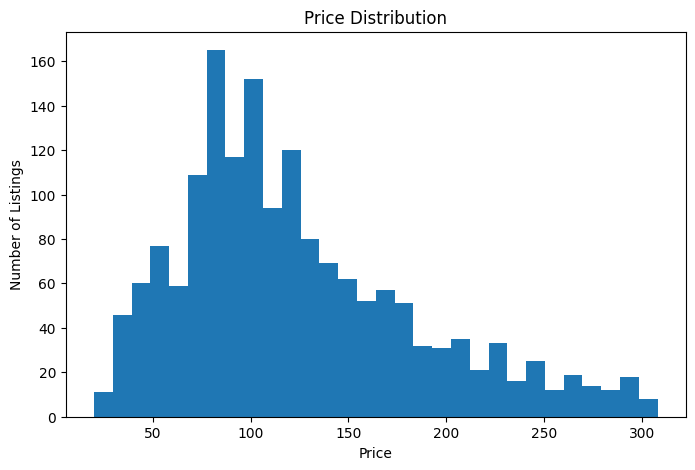

In [16]:
plt.figure(figsize=(8,5)) 
plt.hist(df_cleaned['price'], bins=30) 
plt.xlabel("Price") 
plt.ylabel("Number of Listings") 
plt.title("Price Distribution") 
plt.show() 

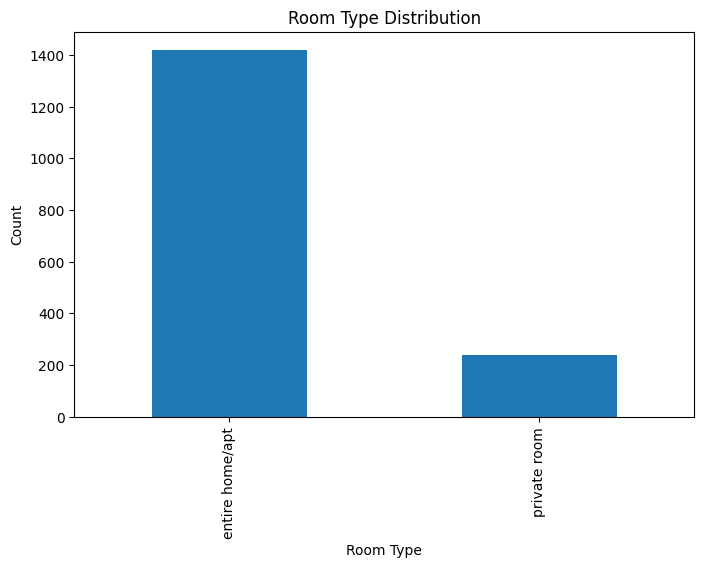

In [17]:
df_cleaned['room_type'].value_counts().plot(kind='bar', figsize=(8,5)) 
plt.xlabel("Room Type") 
plt.ylabel("Count") 
plt.title("Room Type Distribution") 
plt.show() 

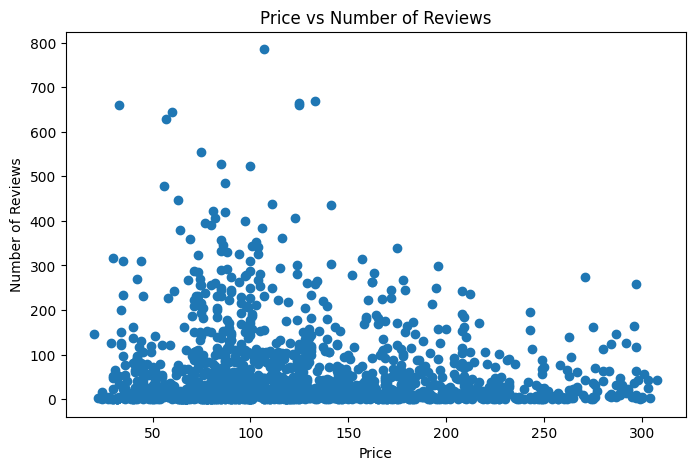

In [18]:
plt.figure(figsize=(8,5)) 
plt.scatter(df_cleaned['price'], df_cleaned['number_of_reviews']) 
plt.xlabel("Price") 
plt.ylabel("Number of Reviews") 
plt.title("Price vs Number of Reviews") 
plt.show() 

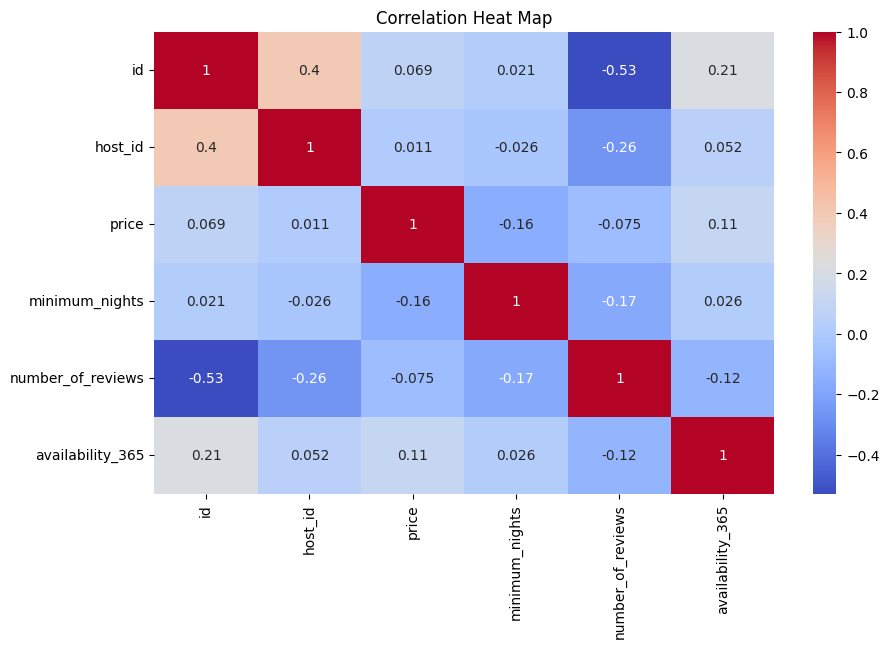

In [19]:
plt.figure(figsize=(10,6)) 
sns.heatmap(df_cleaned[numeric_cols].corr(), annot=True, cmap="coolwarm") 
plt.title("Correlation Heat Map") 
plt.show() 